<a href="https://colab.research.google.com/github/AMJAMAITHILI/DL_LAB/blob/main/DL_WEEK11_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1370 - val_loss: 0.0809
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0747 - val_loss: 0.0701
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0688 - val_loss: 0.0672
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0669 - val_loss: 0.0661
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0659 - val_loss: 0.0653
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0653 - val_loss: 0.0650
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0649 - val_loss: 0.0646
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0647 - val_loss: 0.0644
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0644 - val_loss: 0.0641
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0642 - val_loss: 0.0640
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0641 - val_loss: 0.0639
E

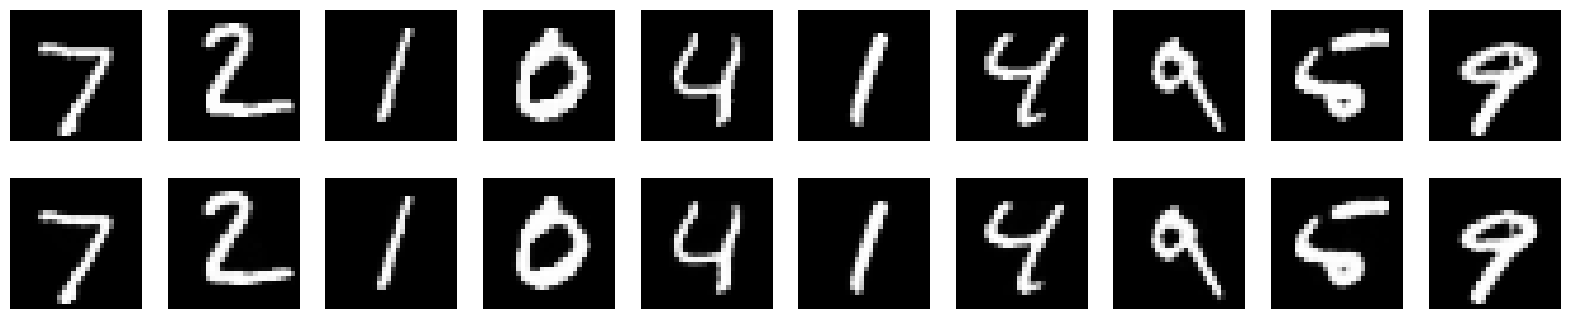

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Encoded activations shape: (10000, 1024)
Top 10 neurons by average activation index:
[  1 139 943 868 500 881 425 882 238  22]
Their average activation values:
[3.0198407 2.9519203 2.7830849 2.761906  2.6917057 2.685924  2.6369305
 2.5416033 2.5169816 2.4024758]


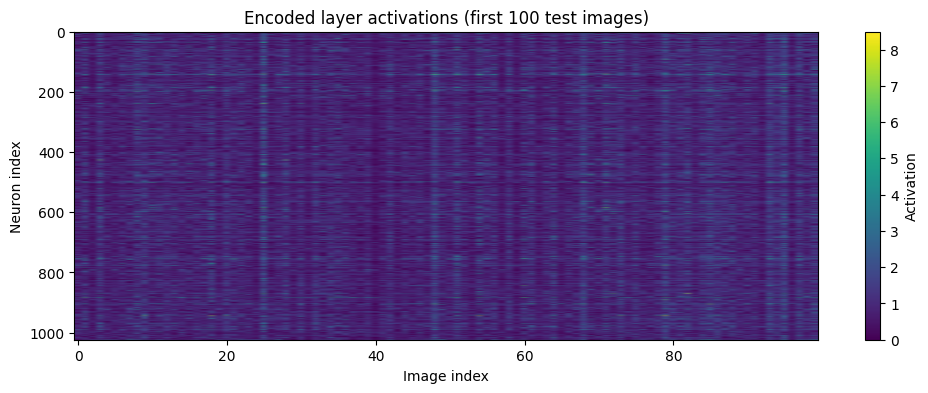

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))
input_dim = 784
encoding_dim = 1024  # Overcomplete layer

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)

overcomplete_ae = Model(input_layer, decoded)
overcomplete_ae.compile(optimizer='adam', loss='binary_crossentropy')
overcomplete_ae.fit(x_train, x_train,
                    epochs=20,
                    batch_size=256,
                    shuffle=True,
                    validation_data=(x_test, x_test))
decoded_imgs = overcomplete_ae.predict(x_test)
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()
encoder = Model(input_layer, encoded)
encoded_imgs = encoder.predict(x_test)  # Shape: (num_samples, 1024)
print("Encoded activations shape:", encoded_imgs.shape)
# Average activation per neuron across all test images
avg_activation = np.mean(encoded_imgs, axis=0)
# Sort neurons by average activation
sorted_idx = np.argsort(avg_activation)[::-1]  # descending order
print("Top 10 neurons by average activation index:")
print(sorted_idx[:10])
print("Their average activation values:")
print(avg_activation[sorted_idx[:10]])
plt.figure(figsize=(12, 4))
plt.imshow(encoded_imgs[:100].T, aspect='auto', cmap='viridis')  # first 100 images
plt.colorbar(label='Activation')
plt.xlabel("Image index")
plt.ylabel("Neuron index")
plt.title("Encoded layer activations (first 100 test images)")
plt.show()

Y-axis: neuron indices (0 to 1023)

X-axis: first 100 images from the test set

Colors: activation values of neurons (dark = low/zero activation, bright = high activation)

The heatmap shows how strongly each neuron activates for each image.

In [ ]:
# Get indices of the 20 neurons with the smallest average activations
least_20_idx = np.argsort(avg_activation)[:20]

print("Least 20 neurons by average activation index:")
print(least_20_idx)

print("Their average activation values:")
print(avg_activation[least_20_idx])

Least 20 neurons by average activation index:
[ 361   38  697  507  270  584  152 1013  659  167  851  485  883 1002
  921  513  789  791  524   55]
Their average activation values:
[0.0000000e+00 0.0000000e+00 9.8073906e-06 4.0413190e-05 8.7121574e-05
 2.1352442e-03 4.9030185e-02 7.5647093e-02 7.6103620e-02 1.3826287e-01
 1.9846733e-01 2.2028513e-01 2.2841856e-01 2.3263511e-01 2.3351797e-01
 2.3780498e-01 2.6832154e-01 3.0757633e-01 3.1031650e-01 3.1659612e-01]


It has extra capacity, but only a subset is strongly used.

The less active neurons might still capture rare or subtle image features.

Adding sparsity regularization could push many of those weakly active neurons to become fully inactive, improving efficiency and interpretability.

**Implement Regularization in AE and demonstrate its use.**

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras import regularizers
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))
input_dim = 784
encoding_dim = 128
input_layer = Input(shape=(input_dim,))
encoded_no_reg = Dense(encoding_dim, activation='relu')(input_layer)
decoded_no_reg = Dense(input_dim, activation='sigmoid')(encoded_no_reg)
ae_no_reg = Model(input_layer, decoded_no_reg)
ae_no_reg.compile(optimizer='adam', loss='binary_crossentropy')
ae_no_reg.fit(x_train, x_train, epochs=20, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
# Encoded activations
encoder_no_reg = Model(input_layer, encoded_no_reg)
encoded_imgs_no_reg = encoder_no_reg.predict(x_test)
avg_activation_no_reg = np.mean(encoded_imgs_no_reg, axis=0)

# Top 10 and Least 20 neurons
print("=== WITHOUT Regularization ===")
print("Top 10 neurons by avg activation index:", np.argsort(avg_activation_no_reg)[::-1][:10])
print("Least 20 neurons by avg activation index:", np.argsort(avg_activation_no_reg)[:20])
#Overcomplete AE WITH Sparsity Regularization
encoded_reg = Dense(encoding_dim, activation='relu',
                    activity_regularizer=regularizers.l1(1e-5))(input_layer)
decoded_reg = Dense(input_dim, activation='sigmoid')(encoded_reg)
ae_reg = Model(input_layer, decoded_reg)
ae_reg.compile(optimizer='adam', loss='binary_crossentropy')
ae_reg.fit(x_train, x_train, epochs=20, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
# Encoded activations
encoder_reg = Model(input_layer, encoded_reg)
encoded_imgs_reg = encoder_reg.predict(x_test)
avg_activation_reg = np.mean(encoded_imgs_reg, axis=0)
print("\n=== WITH Sparsity Regularization ===")
print("Top 10 neurons by avg activation index:", np.argsort(avg_activation_reg)[::-1][:10])
print("Least 20 neurons by avg activation index:", np.argsort(avg_activation_reg)[:20])

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.2133 - val_loss: 0.1352
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1178 - val_loss: 0.1033
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0969 - val_loss: 0.0894
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0860 - val_loss: 0.0815
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0798 - val_loss: 0.0768
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0761 - val_loss: 0.0741
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0738 - val_loss: 0.0723
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0722 - val_loss: 0.0710
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0710 - val_loss: 0.0701
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0702 - val_loss: 0.0693
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0695 - val_loss: 0.0688
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

Without regularization:

Final val_loss ≈ 0.0665 → very low reconstruction error.

The network has enough neurons to memorize input perfectly because it’s overcomplete.

With sparsity (L1):
Final val_loss ≈ 0.1551 → slightly higher error.
That’s expected: forcing neurons to stay mostly inactive reduces memorization but encourages efficient feature learning.

Interpretation:

Regularization trades a tiny bit of accuracy for better generalization and feature selectivity.

In [ ]:
import keras
from keras import layers
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
from keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)
n = 10
plt.figure(figsize=(20, 2))
for i in range(1, n + 1):
    ax = plt.subplot(1, n, i)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()
input_img = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(x_train_noisy, x_train,
                epochs=10,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test_noisy, x_test),
                callbacks=[TensorBoard(log_dir='/tmp/tb', histogram_freq=0, write_graph=False)])
decoded_imgs = autoencoder.predict(x_test_noisy)
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.title("Noisy")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.title("Denoised")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.tight_layout()
plt.show()